
<h1> Using MOMENT for Imputation </h1>
<hr>

## Contents
### 1. A Quick Introduction to Imputation
### 2. Loading MOMENT
### 3. Inputs and Outputs
### 4. Zero-shot Imputation
#### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; 4.1 Masking Time Series Patches
#### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; 4.2 Imputation using MOMENT
#### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; 4.3 Results
### 5. Example Code to Fine-tune MOMENT for Imputation

## 1. A Quick Introduction to Imputation

Multivariate time series are prevalent in real world applications such as finance, meteorology and healthcare. These time series often contain missing values due to various reasons, including equipment malfunctions and human errors. Missing values can impede the meaningful analyis of time series, and hence numerous studies have focused on the task of imputing these missing values using machine learning methodologies. In this tutorial, we will use MOMENT to address the issue of missing values. Formally, the imputation task can be defined as follows:

**Problem**: We are given a time series $T = [x_1, ..., x_L], \ x_i \in \mathbb{R}^{C}$ of length $L$ with $C$ channels (sensors or variables), and a boolean mask of same length $mask = [m_1, ..., m_L]$ indicating missing values. The objective of the imputation problem is to infer missing values and recover the original time series.

## 2. Loading MOMENT

We will first install the MOMENT package, load some essential packages and the pre-trained model. 

MOMENT can be loaded in 4 modes: (1) `reconstruction`, (2) `embedding`, (3) `forecasting`, and (4) `classification`.

In the `reconstruction` mode, MOMENT reconstructs input time series, potentially containing missing values. We can solve imputation and anomaly detection problems in this mode. This mode is suitable for solving imputation and anomaly detection tasks. During pre-training, MOMENT is trained to predict the missing values within uniformly randomly masked patches (disjoint sub-sequences) of the input time series, leveraging information from observed data in other patches. As a result, MOMENT comes equipped with a pre-trained reconstruction head, enabling it to address imputation and anomaly detection challenges in a zero-shot manner! Check out the `anomaly_detection.ipynb` notebook for more details!

In the `embedding` model, MOMENT learns a $d$-dimensional embedding (e.g., $d=1024$ for `MOMENT-1-large`) for each input time series. These embeddings can be used for clustering and classification. MOMENT can learn embeddings in a zero-shot setting! Check out `representation_learning.ipynb` and `classification.ipynb` notebooks for more details! 

The `forecasting` and `classification` modes are used for forecasting and classification tasks, respectively. In these modes, MOMENT learns representations which are subsequently mapped to the forecast horizon or the number of classes, using linear forecasting and classification heads. Both the forecasting and classification head are randomly initialized, and therefore must be fine-tuned before use. Check out the `forecasting.ipynb` and `classification.ipynb` notebooks for more details!

In [9]:
!pip install numpy pandas scikit-learn matplotlib tqdm
!pip install git+https://github.com/moment-timeseries-foundation-model/moment.git

/bin/bash: warning: setlocale: LC_ALL: cannot change locale (en_US.UTF-8)
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3.9 -m pip install --upgrade pip
/bin/bash: warning: setlocale: LC_ALL: cannot change locale (en_US.UTF-8)
Defaulting to user installation because normal site-packages is not writeable
  Cloning https://github.com/moment-timeseries-foundation-model/moment.git to /tmp/pip-req-build-e8a0h_u4
  Running command git clone --filter=blob:none --quiet https://github.com/moment-timeseries-foundation-model/moment.git /tmp/pip-req-build-e8a0h_u4
  Resolved https://github.com/moment-timeseries-foundation-model/moment.git to commit 284d7ff16a817cbdb1337ffc7f7fa5146453a50c
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
INFO: pip is looking at multiple versions of momentfm to

In [5]:
from wrapper.AlgoPython.Moment.momentfm.utils.utils import control_randomness
control_randomness(seed=13) # Set random seeds for PyTorch, Numpy etc.

In [6]:
from wrapper.AlgoPython.Moment.momentfm.models.moment import MOMENTPipeline

size = "small"

if size == "small":
    model = MOMENTPipeline.from_pretrained(
    "AutonLab/MOMENT-1-small",
    model_kwargs={'task_name': 'reconstruction'}
    )
elif size == "medium":
    model = MOMENTPipeline.from_pretrained(
    "AutonLab/MOMENT-1-base",
    model_kwargs={'task_name': 'reconstruction'}
    )
else:
    model = MOMENTPipeline.from_pretrained(
        "AutonLab/MOMENT-1-large",
        model_kwargs={'task_name': 'reconstruction'} # For imputation, we will load MOMENT in `reconstruction` mode
        # local_files_only=True,  # Whether or not to only look at local files (i.e., do not try to download the model).
    )

In [7]:
model.init()
print(model)

MOMENTPipeline(
  (normalizer): RevIN()
  (tokenizer): Patching()
  (patch_embedding): PatchEmbedding(
    (value_embedding): Linear(in_features=8, out_features=512, bias=False)
    (position_embedding): PositionalEmbedding()
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): T5Stack(
    (embed_tokens): Embedding(32128, 512)
    (block): ModuleList(
      (0): T5Block(
        (layer): ModuleList(
          (0): T5LayerSelfAttention(
            (SelfAttention): T5Attention(
              (q): Linear(in_features=512, out_features=384, bias=False)
              (k): Linear(in_features=512, out_features=384, bias=False)
              (v): Linear(in_features=512, out_features=384, bias=False)
              (o): Linear(in_features=384, out_features=512, bias=False)
              (relative_attention_bias): Embedding(32, 6)
            )
            (layer_norm): T5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): T5LayerFF(
            (

In [8]:
# Number of parameters in the encoder
num_params = sum(p.numel() for p in model.encoder.parameters())
print(f"Number of parameters: {num_params}")

Number of parameters: 35332800


## 3. Inputs and Outputs

Let's begin by performing a forward pass through MOMENT and examining its outputs!

MOMENT takes 3 inputs: 
1. An input time series of length $T=512$ timesteps and $C$ channels, and 
2. Two optional masks, both of length $T=512$. 
    - The input mask is utilized to regulate the time steps or patches that the model should attend to. For instance, in the case of shorter time series, you may opt not to attend to padding. To implement this, you can provide an input mask with zeros in the padded locations.  
    - The second mask, referred to simply as mask, denotes masked or unobserved values. We employ mask tokens to replace all patches containing any masked time step (for further details, refer to Section 3.2 in our [paper](https://arxiv.org/abs/2402.03885)). MOMENT can attend to these mask tokens during reconstruction.
    - By default, all time steps are observed and attended to.

MOMENT returns a `TimeseriesOutputs` object. Since this is a reconstruction task, it returns a `reconstruction` of the input.

In [19]:
from pprint import pprint
import torch
import numpy as np
# takes in tensor of shape [batch_size, n_channels, context_length]
from recovery.manager import TimeSeries
from recovery.contamination import GenGap
from tools import utils

# initialize the time series object
ts = TimeSeries()
print(f"\nMissingness patterns : {ts.patterns}")

# load and normalize the dataset
ts.load_series(utils.search_path("chlorine"), normalizer="z_score")

# contaminate the time series with MCAR pattern

original_1 = ts.data.shape[0]
seq = 48

ts_m = GenGap.mcar(ts.data, rate_dataset=0.2, rate_series=0.4, block_size=10, seed=True)

x = utils.window_truncation(ts_m, seq_len=seq, stride=1, info="moments", verbose=True, deep_verbose=True)
x = torch.as_tensor(x)          # converts numpy -> torch (keeps dtype if possible)

print(f"{x.shape = }")


ImputeGAP Library has been invoked (https://github.com/eXascaleInfolab/ImputeGAP)


Missingness patterns : ['aligned', 'disjoint', 'distribution', 'gaussian', 'mcar', 'overlap', 'scattered']

(SYS) The dataset is loaded from /mnt/c/Users/nquen/switchdrive/MST_MasterThesis/imputegap/imputegap/datasets/chlorine.txt

> logs: normalization (z_score) of the data - runtime: 0.0009 seconds

(CONT) missigness pattern: MCAR
	selected series: 14, 18, 20, 26, 27, 31, 33, 40, 46, 49
	percentage of contaminated series: 20.0%
	rate of missing data per series: 40.0%
	block size: 10
	security offset: [0-100]
	seed value: 42

start_indices = array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
      

In [27]:
#x = torch.randn(16, 1, 512)
x_enc = x.permute(0, 2, 1).contiguous()   # [B, C, L]

print(f"{x_enc.shape = }")

# Fill NaNs in x (model also nan_to_num later, but do it early to be safe)
x_filled = torch.nan_to_num(x_enc, nan=0.0)

output = model(x_enc=x_filled)


x_enc.shape = torch.Size([953, 50, 48])


In [28]:
print(f"{output = }")
print(f"{output.reconstruction.shape = }")

output = TimeseriesOutputs(forecast=None, anomaly_scores=None, logits=None, labels=None, input_mask=tensor([[1., 1., 1.,  ..., 1., 1., 1.],
        [1., 1., 1.,  ..., 1., 1., 1.],
        [1., 1., 1.,  ..., 1., 1., 1.],
        ...,
        [1., 1., 1.,  ..., 1., 1., 1.],
        [1., 1., 1.,  ..., 1., 1., 1.],
        [1., 1., 1.,  ..., 1., 1., 1.]]), pretrain_mask=tensor([[1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        ...,
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1]]), reconstruction=tensor([[[-1.6272e+00, -2.0667e+00, -1.7627e+00,  ..., -8.1347e-01,
          -1.5072e+00, -2.4794e+00],
         [-3.3308e+00, -3.5589e+00, -3.7746e+00,  ..., -3.7184e+00,
          -2.0926e+00, -4.5485e+00],
         [-3.4131e+00, -3.5870e+00, -3.7155e+00,  ..., -3.7573e+00,
          -2.8281e+00, -3.8826e+00],
         ...,
         [-1.6022e+00, -1.6022e+00, -1.6022e+00,  ..., -1.6022e+00,


In [29]:
import numpy as np
recovery = output.reconstruction.permute(0, 2, 1).contiguous()   # [B, L, C]
print(f"{recovery.shape = }")

recovery_matrix = utils.reconstruction_window_based(preds=recovery, nbr_timestamps=1000, sliding_windows=1, verbose=True, deep_verbose=False)
print(f"{recovery_matrix.shape = }")

recovery_matrix = recovery_matrix.detach().cpu().numpy()

if np.isnan(recovery_matrix).any():
    print("NAns")



recovery.shape = torch.Size([953, 48, 50])

reconstruction of the windows shaped matrix...
	setup : N =953, L =48, F =50 -> T = 1000 :  the reconstruction has been done successfully, full recovery matrix.
	number of time steps reconstructed: 1000/1000, number of values not handled: 0
recovery_matrix.shape = torch.Size([1000, 50])


In [30]:
from recovery.imputation import Imputation
imputer = Imputation.MatrixCompletion.CDRec(ts_m)

imputer.recov_data = recovery_matrix
# compute and print the imputation metrics
imputer.score(ts.data, imputer.recov_data)
ts.print_results(imputer.metrics)

# plot the recovered time series
ts.plot(input_data=ts.data, incomp_data=ts_m, recov_data=imputer.recov_data, nbr_series=9, subplot=True, algorithm=imputer.algorithm, save_path="./imputegap_assets/imputation")


Results :
RMSE                 = 0.6644874095835857
MAE                  = 0.5704972648998468
MI                   = 0.4439753853857084
CORRELATION          = 0.7571520040199443

plots saved in: ./imputegap_assets/imputation/26_02_10_15_25_37_cdrec_plot.jpg


'./imputegap_assets/imputation/26_02_10_15_25_37_cdrec_plot.jpg'

## 4. Zero-shot Imputation

Now we'll show you how to use MOMENT to do zero-shot imputation!

In these experiments, we will use Hourly Electricity Transformer Temperature (ETTh1) dataset introduced by [Zhou et al., 2020](https://arxiv.org/abs/2012.07436). Check out [ETDataset](https://github.com/zhouhaoyi/ETDataset) for more information! We will use the ETTh1 dataset since missing values are common in this domain!

We'll start by reading and pre-processing this dataset using the `InformerDataset` class. Since we can do zero-shot imputation, we will just load the testing part of this data. Note that MOMENT was not exposed to the testing part of this dataset during pre-training.

In [1]:
from pprint import pprint
import torch
import numpy as np
# takes in tensor of shape [batch_size, n_channels, context_length]
from recovery.manager import TimeSeries
from recovery.contamination import GenGap
from tools import utils

# initialize the time series object
ts = TimeSeries()
print(f"\nMissingness patterns : {ts.patterns}")

# load and normalize the dataset
ts.load_series(utils.search_path("chlorine"), normalizer="z_score")

# contaminate the time series with MCAR pattern

original_1 = ts.data.shape[0]
seq = 48

ts_m = GenGap.mcar(ts.data, rate_dataset=0.2, rate_series=0.4, block_size=10, seed=True)


ImputeGAP Library has been invoked (https://github.com/eXascaleInfolab/ImputeGAP)


Missingness patterns : ['aligned', 'disjoint', 'distribution', 'gaussian', 'mcar', 'overlap', 'scattered']

(SYS) The dataset is loaded from /mnt/c/Users/nquen/switchdrive/MST_MasterThesis/imputegap/imputegap/datasets/chlorine.txt

> logs: normalization (z_score) of the data - runtime: 0.0009 seconds

(CONT) missigness pattern: MCAR
	selected series: 14, 18, 20, 26, 27, 31, 33, 40, 46, 49
	percentage of contaminated series: 20.0%
	rate of missing data per series: 40.0%
	block size: 10
	security offset: [0-100]
	seed value: 42



In [2]:
from wrapper.AlgoPython.Moment.momentfm.data.informer_dataset import InformerDataset
from torch.utils.data import DataLoader

test_dataset = InformerDataset(
    data_split='test',
    task_name='imputation',
    data_stride_len=1,
    ts_m=ts_m)

print(f"{test_dataset.data = }")

test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=False)


2026-02-10 17:13:27.489194: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-10 17:13:27.541199: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-10 17:13:29.711458: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


test_dataset.data = array([[-2.31117917, -4.02023408, -3.88030348, ..., -1.60218595,
        -1.42943033, -1.64926714],
       [-2.32516654, -4.0329799 , -3.8893548 , ..., -1.60218595,
        -1.42943033, -1.64926716],
       [-2.33915426, -4.04572572, -3.89840666, ..., -1.60218595,
        -1.42943033, -1.64926718],
       ...,
       [-0.9125889 ,  0.24852332,  0.30795923, ...,  1.09185111,
                nan,  0.51751013],
       [-0.93260182,  0.21411962,  0.273891  , ...,  1.06543289,
                nan,  0.48758449],
       [-0.94934276,  0.17921287,  0.23944078, ...,  1.02617306,
                nan,  0.4565672 ]], shape=(1000, 50))


Now let's visualize the time series

In [3]:
import numpy as np
import matplotlib.pyplot as plt

n_channels = test_dataset[0][0].shape[0]
idx = np.random.randint(0, len(test_dataset))
channel_idx = np.random.randint(0, n_channels)
plt.plot(test_dataset[idx][0][channel_idx, :].squeeze(), c='darkblue')
plt.title(f'idx={idx}  | channel={channel_idx}')
plt.show()

### 4.1 Masking Time Series Patches

Since there are no missing values in this dataset, we will randomly mask time series subsequences to evaluate MOMENT's ability to reason about missing values. Instead of masking individual time steps at random, we will mask time series patches uniformly at random using the `Masking` class.

In [14]:
from wrapper.AlgoPython.Moment.momentfm.utils.masking import Masking

mask_generator = Masking(mask_ratio=0.25) # Mask 25% of patches randomly 

### 4.2 Imputation using MOMENT

Since there are no missing values in this dataset, we will randomly mask time series subsequences to evaluate MOMENT's ability to reason about missing values. Instead of masking individual time steps at random, we will mask time series patches uniformly at random using the `Masking` class.

In [15]:
from tqdm import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device).float()

trues, preds, masks = [], [], []
with torch.no_grad():
    for batch_x, batch_masks, _ in tqdm(test_dataloader, total=len(test_dataloader)):


        trues.append(batch_x.numpy())
        
        batch_x = batch_x.to(device).float()
        n_channels = batch_x.shape[1]
        
        # Reshape to [batch_size * n_channels, 1, window_size]
        batch_x = batch_x.reshape((-1, 1, 48))
        
        batch_masks = batch_masks.to(device).long()
        batch_masks = batch_masks.repeat_interleave(n_channels, axis=0)
        
        mask = mask_generator.generate_mask(x=batch_x, input_mask=batch_masks).to(device).long()

        print(f"{batch_x.shape = }")
        print(f"{batch_masks.shape = }")
        print(f"{mask.shape = }")

        #mask = batch_mask

        output = model(x_enc=batch_x, input_mask=batch_masks, mask=mask) # [batch_size, n_channels, window_size]
        
        reconstruction = output.reconstruction.detach().cpu().numpy()
        mask = mask.detach().squeeze().cpu().numpy()
        
        # Reshape back to [batch_size, n_channels, window_size]
        reconstruction = reconstruction.reshape((-1, n_channels, 48))
        mask = mask.reshape((-1, n_channels, 48))
                
        preds.append(reconstruction)
        masks.append(mask)

preds = np.concatenate(preds)
trues = np.concatenate(trues)
masks = np.concatenate(masks)

print(f"Shapes: preds={preds.shape} | trues={trues.shape} | masks={masks.shape}")

  0%|          | 0/15 [00:00<?, ?it/s]

batch_x.shape = torch.Size([3200, 1, 48])
batch_masks.shape = torch.Size([3200, 48])
mask.shape = torch.Size([3200, 48])


/home/naterq/.virtualenvs/imputegap/lib/python3.12/site-packages/torch/utils/checkpoint.py:85: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(
  7%|▋         | 1/15 [00:01<00:21,  1.56s/it]

batch_x.shape = torch.Size([3200, 1, 48])
batch_masks.shape = torch.Size([3200, 48])
mask.shape = torch.Size([3200, 48])


 13%|█▎        | 2/15 [00:02<00:13,  1.01s/it]

...

batch_x.shape = torch.Size([3200, 1, 48])
batch_masks.shape = torch.Size([3200, 48])
mask.shape = torch.Size([3200, 48])


 93%|█████████▎| 14/15 [00:09<00:00,  1.61it/s]

batch_x.shape = torch.Size([2850, 1, 48])
batch_masks.shape = torch.Size([2850, 48])
mask.shape = torch.Size([2850, 48])


100%|██████████| 15/15 [00:10<00:00,  1.48it/s]

Shapes: preds=(953, 50, 48) | trues=(953, 50, 48) | masks=(953, 50, 48)


In [24]:
import numpy as np
print(f"{preds.shape = }")
recovery = np.transpose(preds, (0, 2, 1))  # (B, L, C)
recovery = np.ascontiguousarray(recovery)

print(f"{recovery.shape = }")

recovery_matrix = utils.reconstruction_window_based(preds=recovery, nbr_timestamps=1000, sliding_windows=1, verbose=True, deep_verbose=False)
print(f"{recovery_matrix.shape = }")

recovery_matrix = recovery_matrix.numpy()

if np.isnan(recovery_matrix).any():
    print("NAns")



preds.shape = (953, 50, 48)
recovery.shape = (953, 48, 50)

reconstruction of the windows shaped matrix...
	setup : N =953, L =48, F =50 -> T = 1000 :  the reconstruction has been done successfully, full recovery matrix.
	number of time steps reconstructed: 1000/1000, number of values not handled: 0
recovery_matrix.shape = torch.Size([1000, 50])
NAns


### 4.3 Results

Since there are no missing values in this dataset, we will randomly mask time series subsequences to evaluate MOMENT's ability to reason about missing values. Instead of masking individual time steps at random, we will mask time series patches uniformly at random using the `Masking` class.

In [10]:
from momentfm.utils.forecasting_metrics import mse, mae

print(f"Mean Squarred Error (MSE)={mse(y=trues[masks==0], y_hat=preds[masks==0], reduction='mean')}")
print(f"Mean Absolute Error (MAE)={mae(y=trues[masks==0], y_hat=preds[masks==0], reduction='mean')}")

Mean Squarred Error (MSE)=0.3958190247397213
Mean Absolute Error (MAE)=0.38577987663802804


Now let's visualize random time series windows! White patches are masked and black patches are observed.

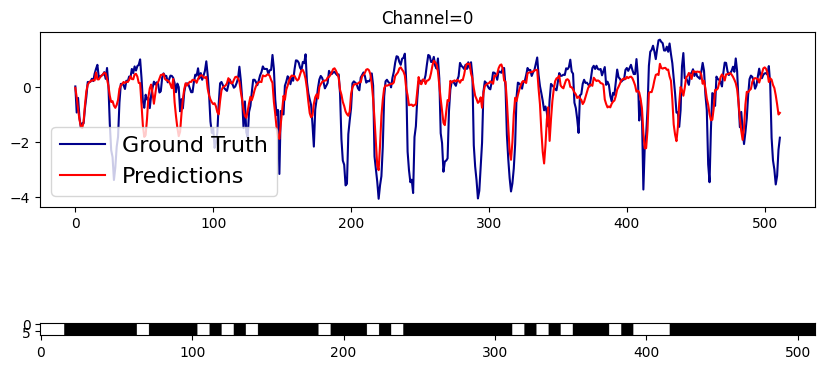

In [11]:
idx = np.random.randint(trues.shape[0])
channel_idx = np.random.randint(trues.shape[1])

fig, axs = plt.subplots(2, 1, figsize=(10, 5))
axs[0].set_title(f"Channel={channel_idx}")
axs[0].plot(trues[idx, channel_idx, :].squeeze(), label='Ground Truth', c='darkblue')
axs[0].plot(preds[idx, channel_idx, :].squeeze(), label='Predictions', c='red')
axs[0].legend(fontsize=16)

axs[1].imshow(np.tile(masks[np.newaxis, idx, channel_idx], reps=(8, 1)), cmap='binary')
plt.show()

## 5. Example Code to Fine-tune MOMENT for Imputation

To improve MOMENT's imputation performance, you can fine-tune it on any dataset. In our [paper](https://arxiv.org/abs/2402.03885), we fine-tune the final reconstruction head, but you can also fine-tune the entire model on your data. Here is some example code:

```python

# Optimize Mean Squarred Error using your favourite optimizer
criterion = torch.nn.MSELoss() 
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

mask_generator = Masking(mask_ratio=0.3) # Mask 30% of patches randomly 

for batch_x, batch_masks in tqdm(test_dataloader, total=len(test_dataloader)):
    n_channels = batch_x.shape[1]
    
    # Reshape to [batch_size * n_channels, 1, window_size]
    batch_x = batch_x.reshape((-1, 1, 512)) 
    
    batch_masks = batch_masks.to(device).long()
    batch_masks = batch_masks.repeat_interleave(n_channels, axis=0)
    
    # Randomly mask some patches of data
    mask = mask_generator.generate_mask(
        x=batch_x, input_mask=batch_masks).to(device).long()

    # Forward
    output = model(x_enc=batch_x, input_mask=batch_masks, mask=mask) 
    
    # Compute loss
    recon_loss = criterion(output.reconstruction, original)
    observed_mask = batch_masks * (1 - mask)
    masked_loss = observed_mask * recon_loss
    
    loss = masked_loss.nansum() / (observed_mask.nansum() + 1e-7)
    
    print(f"loss: {loss.item()}")
    
    # Backward
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
```